In [1]:
import zipfile
from google.colab import files
import os

print("Please upload your zipped image dataset folder (e.g., 'images.zip').")

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the uploaded file is a zip archive
  try:
    with zipfile.ZipFile(fn, 'r') as zip_ref:
      zip_ref.extractall(os.path.join(os.getcwd(), 'dataset')) # Extract to a 'dataset' folder
    print(f'Successfully extracted "{fn}" to the "dataset" folder.')
  except zipfile.BadZipFile:
    print(f'Error: "{fn}" is not a valid zip file. Please upload a zip archive.')
  except Exception as e:
    print(f'An unexpected error occurred: {e}')

# List the contents of the created 'dataset' folder to confirm
if os.path.exists('dataset'):
  print('\nContents of the \'dataset\' folder:')
  for root, dirs, files in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
      print(f'{subindent}{f}')
else:
  print('\nNo \'dataset\' folder was created.')

Please upload your zipped image dataset folder (e.g., 'images.zip').


Saving Flower_Dataset.zip to Flower_Dataset.zip
User uploaded file "Flower_Dataset.zip" with length 215160703 bytes
Successfully extracted "Flower_Dataset.zip" to the "dataset" folder.

Contents of the 'dataset' folder:
dataset/
    Flower_Dataset/
        test/
            Image_611.jpg
            Image_223.jpg
            Image_354.jpg
            Image_763.jpg
            Image_692.jpg
            Image_8.jpg
            Image_53.jpg
            Image_618.jpg
            Image_502.jpg
            Image_590.jpg
            Image_664.jpg
            Image_22.jpg
            Image_659.jpg
            Image_480.jpg
            Image_248.jpg
            Image_408.jpg
            Image_350.jpg
            Image_613.jpg
            Image_429.jpg
            Image_145.jpg
            Image_81.jpg
            Image_67.jpg
            Image_639.jpg
            Image_2.jpg
            Image_454.jpg
            Image_789.jpg
            Image_146.jpg
            Image_784.jpg
            Image

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

# Suppress TensorFlow logging to only show errors
tf.get_logger().setLevel('ERROR')

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Path to the dataset directory (training and validation will be split from this)
data_dir = 'dataset/Flower_Dataset/train'

print(f"Loading data from: {data_dir}")

# Create training dataset with a validation split
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # 20% of data for validation
    subset='training',
    seed=123, # For reproducibility
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Create validation dataset from the same directory and split
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # Same split percentage
    subset='validation',
    seed=123, # Same seed for consistent split
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Get class names and number of classes
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets loaded and configured.")

Loading data from: dataset/Flower_Dataset/train
Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.
Found 5 classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Datasets loaded and configured.


In [11]:
# Data augmentation layers
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ],
  name="data_augmentation"
)

# Rescaling layer for pixel normalization
preprocess_input = layers.Rescaling(1./255, name="rescaling")

# Define the Fire Module
def fire_module(x, squeeze_filters, expand_filters, name):
    squeeze = layers.Conv2D(squeeze_filters, (1, 1), activation='relu', padding='same', name=f'{name}_squeeze')(x)
    expand_1x1 = layers.Conv2D(expand_filters, (1, 1), activation='relu', padding='same', name=f'{name}_expand_1x1')(squeeze)
    expand_3x3 = layers.Conv2D(expand_filters, (3, 3), activation='relu', padding='same', name=f'{name}_expand_3x3')(squeeze)
    return layers.concatenate([expand_1x1, expand_3x3], axis=-1, name=f'{name}_concat')

# Define the SqueezeNet Model
def SqueezeNet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=num_classes):
    input_tensor = keras.Input(shape=input_shape)

    x = data_augmentation(input_tensor) # Apply augmentation
    x = preprocess_input(x) # Apply normalization

    x = layers.Conv2D(96, (7, 7), strides=(2, 2), activation='relu', padding='same', name='conv1')(x)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same', name='maxpool1')(x)

    x = fire_module(x, 16, 64, name='fire2')
    x = fire_module(x, 16, 64, name='fire3')
    x = fire_module(x, 32, 128, name='fire4')
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same', name='maxpool4')(x)

    x = fire_module(x, 32, 128, name='fire5')
    x = fire_module(x, 48, 192, name='fire6')
    x = fire_module(x, 48, 192, name='fire7')
    x = fire_module(x, 64, 256, name='fire8')
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same', name='maxpool8')(x)

    x = fire_module(x, 64, 256, name='fire9')
    x = layers.Dropout(0.5, name='dropout9')(x) # Added dropout for regularization

    # Final convolutional layer for classification instead of fully connected
    x = layers.Conv2D(num_classes, (1, 1), activation='relu', padding='same', name='conv10')(x)
    x = layers.GlobalAveragePooling2D(name='avgpool10')(x) # Global average pooling
    output = layers.Activation('softmax', name='softmax')(x) # Softmax activation for multi-class classification

    model = keras.Model(inputs=input_tensor, outputs=output, name='SqueezeNet')
    return model

print("SqueezeNet fire_module and model definition complete.")

SqueezeNet fire_module and model definition complete.


In [12]:
# Create the model
model = SqueezeNet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=num_classes)

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display model summary
print("Model Summary:")
model.summary()

# Train the model
epochs = 20 # You can adjust the number of epochs
print(f"\nStarting training for {epochs} epochs...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

print("Training complete.")

Model Summary:


Model: "SqueezeNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 112, 112,  │     14,208 │ rescaling[0][0]   │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1            │ (None, 56, 56,    │          0 │ conv1[0][0]       │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_squeeze       │ (None, 56, 56,    │      1,552 │ maxpool1[0][0]    │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_expand_1x1    │ (None, 56, 56,    │      1,088 │ fire2_squeeze[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_expand_3x3    │ (None, 56, 56,    │      9,280 │ fire2_squeeze[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_concat        │ (None, 56, 56,    │          0 │ fire2_expand_1x1… │
│ (Concatenate)       │ 128)              │            │ fire2_expand_3x3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire3_squeeze       │ (None, 56, 56,    │      2,064 │ fire2_concat[0][… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire3_expand_1x1    │ (None, 56, 56,    │      1,088 │ fire3_squeeze[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire3_expand_3x3    │ (None, 56, 56,    │      9,280 │ fire3_squeeze[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire3_concat        │ (None, 56, 56,    │          0 │ fire3_expand_1x1… │
│ (Concatenate)       │ 128)              │            │ fire3_expand_3x3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire4_squeeze       │ (None, 56, 56,    │      4,128 │ fire3_concat[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire4_expand_1x1    │ (None, 56, 56,    │      4,224 │ fire4_squeeze[0]… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire4_expand_3x3    │ (None, 56, 56,    │     36,992 │ fire4_squeeze[0]… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire4_concat        │ (None, 56, 56,    │          0 │ fire4_expand_1x1

 Total params: 737,989 (2.82 MB)

 Trainable params: 737,989 (2.82 MB)

 Non-trainable params: 0 (0.00 B)


Starting training for 20 epochs...
Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 437s 6s/step - accuracy: 0.2312 - loss: 1.6080 - val_accuracy: 0.2277 - val_loss: 1.6074
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 406s 6s/step - accuracy: 0.2371 - loss: 1.6048 - val_accuracy: 0.2277 - val_loss: 1.6045
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 408s 6s/step - accuracy: 0.2367 - loss: 1.6035 - val_accuracy: 0.2277 - val_loss: 1.6040
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 396s 6s/step - accuracy: 0.2371 - loss: 1.6029 - val_accuracy: 0.2277 - val_loss: 1.6042
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 400s 6s/step - accuracy: 0.2371 - loss: 1.6031 - val_accuracy: 0.2277 - val_loss: 1.6043
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 392s 6s/step - accuracy: 0.2371 - loss: 1.6028 - val_accuracy: 0.2277 - val_loss: 1.6040
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 459s 6s/step - accuracy: 0.2371 - loss: 1.6032 - val_accuracy: 0.2277 - val_loss: 1.6041
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 407s 6s/step - accuracy: 0.2371 - los

In [13]:
print("\n--- Training Results Summary ---")
final_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Final Training Loss: {final_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")


--- Training Results Summary ---
Final Training Accuracy: 0.2371
Final Validation Accuracy: 0.2277
Final Training Loss: 1.6028
Final Validation Loss: 1.6044



--- Training History Plots ---


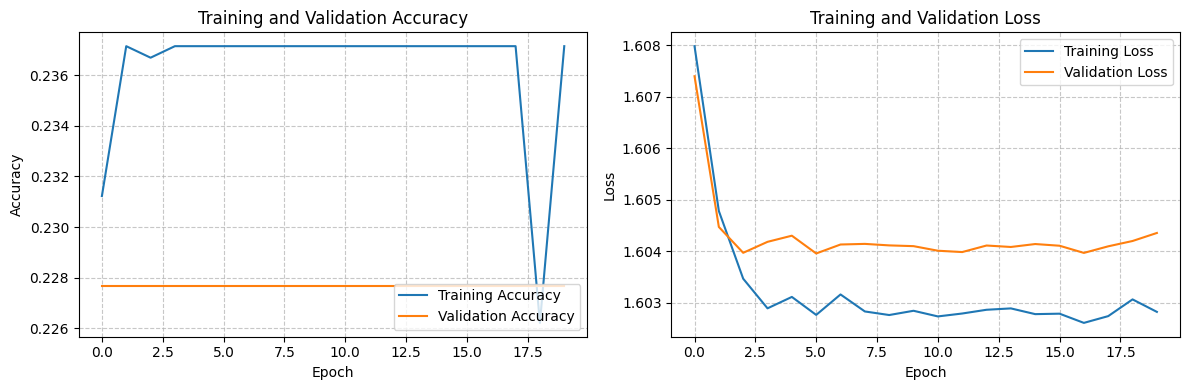

In [14]:
print("\n--- Training History Plots ---")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()